In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Store: Store number**  

**Date: Sales week start date**  

**Weekly_Sales: Sales**  

**Holiday_Flag: Mark on the presence or absence of a holiday**  

**Temperature: Air temperature in the region**  

**Fuel_Price: Fuel cost in the region**  

**CPI: Consumer price index**  

**Unemployment: Unemployment rate**

In [1]:
df = pd.read_csv("Walmart_sales.csv")
df.head(5)

NameError: name 'pd' is not defined

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [6]:
df.shape

(6435, 8)

In [34]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [26]:
cols = [col for col in df.columns if col not in ['Date']]
df_without_date = df[cols]

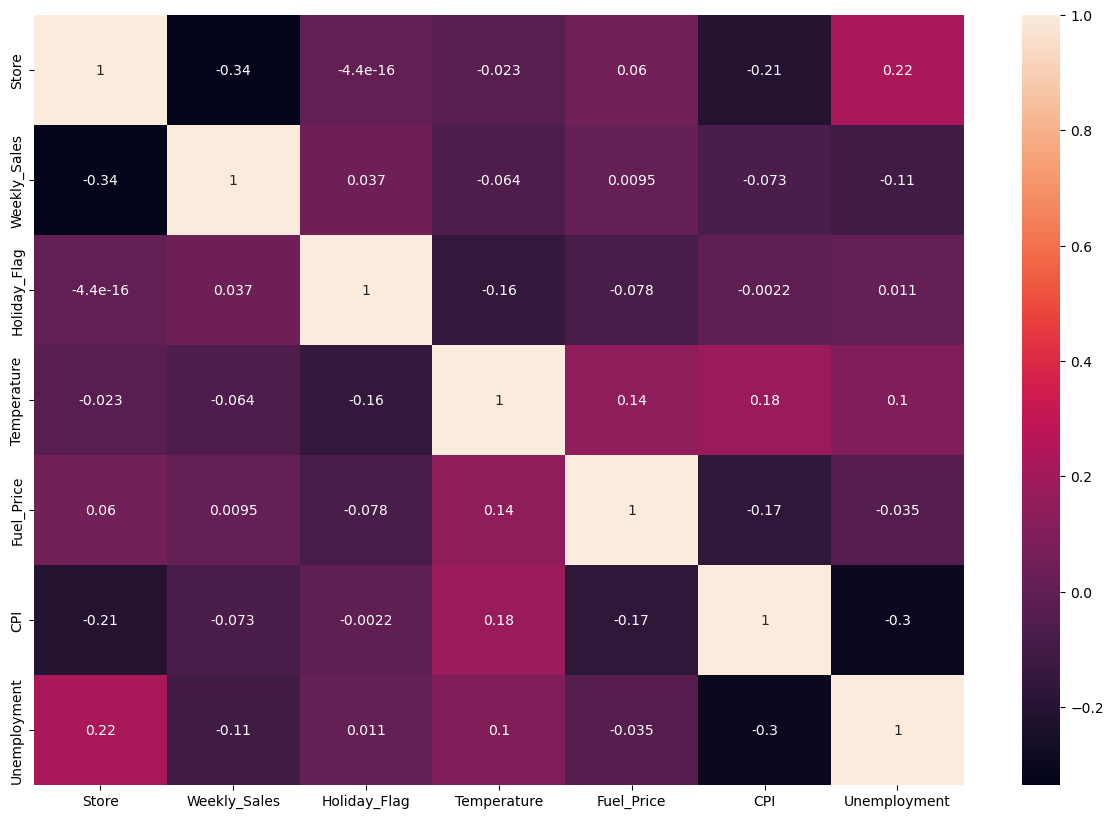

In [32]:
plt.figure(figsize=(15,10))
corr = df_without_date.corr()
ax = sns.heatmap(corr, annot=True)

<h1> Видим, что для таргета Weekly_sales самая высокая корреляция наблюдается у Unemployment<h1>

<function matplotlib.pyplot.show(close=None, block=None)>

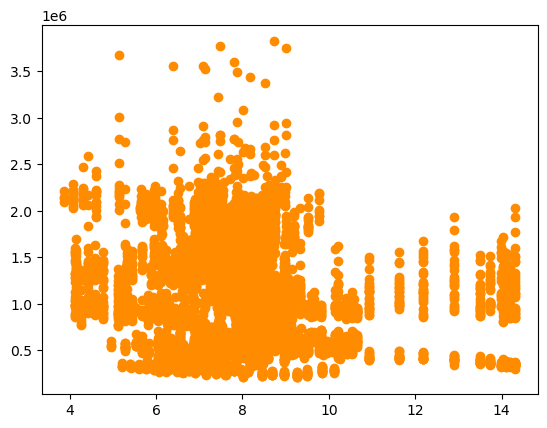

In [35]:
plt.scatter(df['Unemployment'], df['Weekly_Sales'], color='darkorange', 
            label='data') 
plt.show

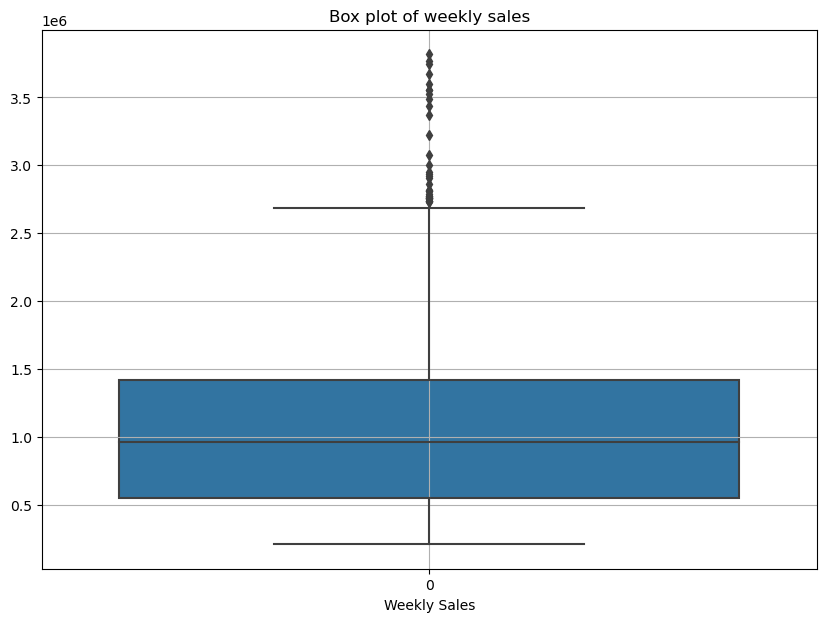

In [36]:
# box plot
plt.figure(figsize=(10, 7))
sns.boxplot(df['Weekly_Sales'])
plt.xlabel("Weekly Sales")
plt.title("Box plot of weekly sales")
plt.grid(True)

<h1> Устроняем выбросы с помощью метода IQR <h1>

In [37]:
Q1 = df["Weekly_Sales"].quantile(0.25)
Q3 = df["Weekly_Sales"].quantile(0.75)

#fing IQR
IQR = Q3-Q1

lower_bound = Q1-IQR*1.5
upper_bound = Q3+IQR*1.5

In [38]:
# 25% значений Weekly_Sales ниже этого числа
Q1

553350.105

In [39]:
# 25% значений Weekly_Sales выше этого числа
Q3

1420158.66

In [40]:
# "Расстояние" между нижней и верхней границей
IQR

866808.5549999999

In [41]:
lower_bound

-746862.7275

In [42]:
upper_bound

2720371.4924999997

In [50]:
df_without_outliers = df[(df["Weekly_Sales"]>=lower_bound ) & (df["Weekly_Sales"]<=upper_bound)]

In [72]:
X = df_without_outliers.drop(['Weekly_Sales', 'Date'],axis=1)
Y = df_without_outliers['Weekly_Sales']


<h1> Линейная регрессия <h1>

In [78]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state = 42)

In [92]:
from sklearn import datasets, linear_model
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import Ridge,Lasso

In [85]:
# изменяем масштаб
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [86]:
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(predictions[:15])

[1319309.07920929  843503.45346952  741575.3319016  1225255.2547482
 1256727.72562139  709167.89878628  714982.77488819  738257.26427124
 1182336.77903437  954372.9269526   841457.20340282  937972.04883685
 1465601.41408328  740725.20344555  847817.62833169]


In [87]:
model.score(X_test,y_test)

0.15743801697205084

In [90]:
mean_absolute_error(y_test, predictions)

431583.5204237343

In [100]:
ridge=Ridge(alpha = 10000)
model=ridge.fit(X_train,y_train)
model.score(X_test,y_test)

0.07549266509431263

In [104]:
lasso=Lasso(alpha = 1000)
model=lasso.fit(X_train,y_train)
model.score(X_test,y_test)

0.15680025089647287

<h1> Линейная регрессия с методом опорных векторов <h1>

In [105]:
from sklearn.svm import SVR

svr = SVR(kernel='linear') 
  
svr.fit(X_train, y_train) 
   
y_pred = svr.predict(X_test) 

In [106]:
model.score(X_test,y_test)

0.15680025089647287

In [107]:
mean_absolute_error(y_test, y_pred)

474540.1091168645

<h1> Случайный лес <h1>

In [116]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=100, random_state=1)
model=rf.fit(X_train,y_train)
model.score(X_test,y_test)

0.9442293175118369

**При увеличении количества деревьев score улучшается не сильно**

In [117]:
y_pred = rf.predict(X_test)
mean_absolute_error(y_test, y_pred)

74967.63407556595

<h1> Нейронная сеть<h1>

In [118]:
import tensorflow as tf
from tensorflow import keras

In [123]:
input_shape = (X_train.shape[1],)
model = tf.keras.Sequential([
 
    tf.keras.layers.Dense(units=300, activation='relu',
                          input_shape=input_shape),
    tf.keras.layers.Dense(units=300, activation='relu'),
    tf.keras.layers.Dense(units=1)
])
model.summary()

C:\Users\vboro\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 300)                 │           2,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 300)                 │          90,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             301 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 92,701 (362.11 KB)

 Trainable params: 92,701 (362.11 KB)

 Non-trainable params: 0 (0.00 B)

In [124]:
model.compile(optimizer='adam',loss='mae')

In [125]:
loss=model.fit(X_train, y_train, epochs=500)

Epoch 1/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 649us/step - loss: 1025161.9375
Epoch 2/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step - loss: 1038989.0625
Epoch 3/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step - loss: 1003468.8750
Epoch 4/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 555us/step - loss: 953822.7500
Epoch 5/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step - loss: 871026.4375
Epoch 6/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 656us/step - loss: 746563.3750
Epoch 7/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 693us/step - loss: 621345.3125
Epoch 8/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step - loss: 538701.6250
Epoch 9/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 562us/step - loss: 492847.1875
Epoch 10/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 607us/step - loss: 460382.2812
Epoch 11/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 631us/step - loss: 452416.4062
Epoch 12/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step - loss: 445194.2500
Epoch 13/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step - loss: 446528.9375
Epoch 14/500
160/1

160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step - loss: 385347.4062
Epoch 150/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step - loss: 385236.7500
Epoch 151/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 536us/step - loss: 384532.7812
Epoch 152/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 542us/step - loss: 382320.2188
Epoch 153/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 634us/step - loss: 388229.7188
Epoch 154/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step - loss: 385517.3125
Epoch 155/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step - loss: 387242.7500
Epoch 156/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step - loss: 380268.4062
Epoch 157/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - loss: 381354.8438
Epoch 158/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step - loss: 384743.0625
Epoch 159/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 607us/step - loss: 388693.5625
Epoch 160/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step - loss: 388479.8750
Epoch 161/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step - loss: 385994.4062
Epoch 162/500

160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 620us/step - loss: 379391.2500
Epoch 296/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step - loss: 382976.7812
Epoch 297/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 647us/step - loss: 383070.3125
Epoch 298/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 642us/step - loss: 381107.6875
Epoch 299/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 588us/step - loss: 378377.7188
Epoch 300/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 586us/step - loss: 375394.2188
Epoch 301/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step - loss: 383417.1562
Epoch 302/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 622us/step - loss: 380244.9688
Epoch 303/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 621us/step - loss: 378484.9688
Epoch 304/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 652us/step - loss: 376171.2812
Epoch 305/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step - loss: 387415.8438
Epoch 306/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 597us/step - loss: 386917.8125
Epoch 307/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step - loss: 372867.9688
Epoch 308/500

160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - loss: 382478.5000
Epoch 442/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 555us/step - loss: 372690.9062
Epoch 443/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step - loss: 378764.9688
Epoch 444/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step - loss: 372629.2500
Epoch 445/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step - loss: 375630.4062
Epoch 446/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 631us/step - loss: 365054.5938
Epoch 447/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 590us/step - loss: 370583.6875
Epoch 448/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step - loss: 370110.6250
Epoch 449/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step - loss: 367329.0000
Epoch 450/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step - loss: 377555.2812
Epoch 451/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step - loss: 368339.7812
Epoch 452/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 648us/step - loss: 375842.2188
Epoch 453/500
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step - loss: 378181.1875
Epoch 454/500

<Axes: >

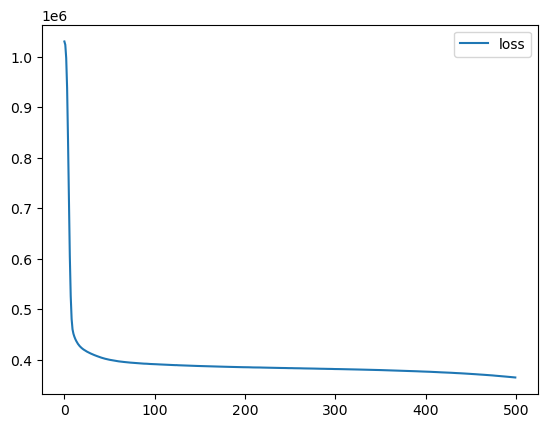

In [126]:
loss_df = pd.DataFrame(loss.history)

loss_df.loc[:,['loss']].plot()

<h1> Можно заметить, что с увеличением числа Эпох после 50 ошибка особо не изменяется <h1>

<h1> Градиентный бустинг Sci-kit<h1>

In [129]:
from sklearn.ensemble import GradientBoostingRegressor

In [135]:
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)
gb.score(X_test, y_test)

0.8971782411442214

In [137]:
# попробуем с mae
gb = GradientBoostingRegressor(loss = 'absolute_error')
gb.fit(X_train, y_train)
gb.score(X_test, y_test)

0.8054203990440124

In [132]:
y_pred = gb.predict(X_test)
mean_absolute_error(y_test, y_pred)

127362.90572671003

<h1> Градиентный бустинг Cat-boost<h1>

In [140]:
pip install catboost

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for catboost from https://files.pythonhosted.org/packages/e8/37/3afd3c02798734efcd7840bfa872d3efc06f5d5c92f9613fea3ff5b4311f/catboost-1.2.3-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for graphviz from https://files.pythonhosted.org/packages/00/be/d59db2d1d52697c6adc9eacaf50e8965b6345cc143f671e1ed068818d5cf/graphviz-0.20.3-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/101.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.1 MB ? eta -:--:--
   ---------------------------------------- 0.1/101.1 MB 1.1 MB/s eta 0:01:37
   ---------------------------------------- 0.2/101.1 MB 1.7 MB/s eta 0:00:59
   ---------------------------------------- 0.6/101.1 MB 3.2 MB/s eta 0:00:32
    --------------------------------------- 1.3/101.1 MB 6.0 MB/s eta 0:00:17
    --------------------------------------- 2.4/101.1 MB

In [141]:
from catboost import CatBoostRegressor
cat = CatBoostRegressor()

In [143]:
cat.fit(X_train,y_train,verbose=False)

In [144]:
cat.score(X_test, y_test)

0.9601555684936959

In [145]:
y_pred = cat.predict(X_test)
mean_absolute_error(y_test, y_pred)

69133.14141876393

<h1>
Вывод: изначально датасет был не очень хорошим, так как (скорее всего) не было фичей с высокой корреляцией с таргетом. Поэтому обычная линейная регрессия, Ridge, Lasso и SVM показали плохие результаты и большие ошибки.  
<h1>

<h1> 
    Нейронная сеть показала более хорошие результаты (разница в MAE около 10%), чем предыдущие методы, но ,учитывая скорость ее тренировки, она не выглядит привлекательнее чем первые методы.<h1>

<h1> Лучше всего себя показали Случайные деревья и Градиентный бустинг. Случайные деревья оказались чуть хуже чем CatBoost. Но обе модели на 5-6% лучше чем градиентный бустинг от Scikit-learn<h1>